# SECTOR ANALYSIS - Utilities

check if makes sense: https://www.spglobal.com/spdji/en/index-family/equity/us-equity/sp-sectors/#overview


In [1]:
import pandas as pd
from pathlib import Path
import os

os.chdir(Path.cwd().parent.parent)

sector_name = "Utilities"
save_path= "backtest/attachments"


In [2]:
df = pd.read_csv("backtest/data/backtest_data.csv")
df = df[df["sector"] == sector_name]

Gespeichert: backtest/attachments/utilities/value_score_Renditedreieck.png


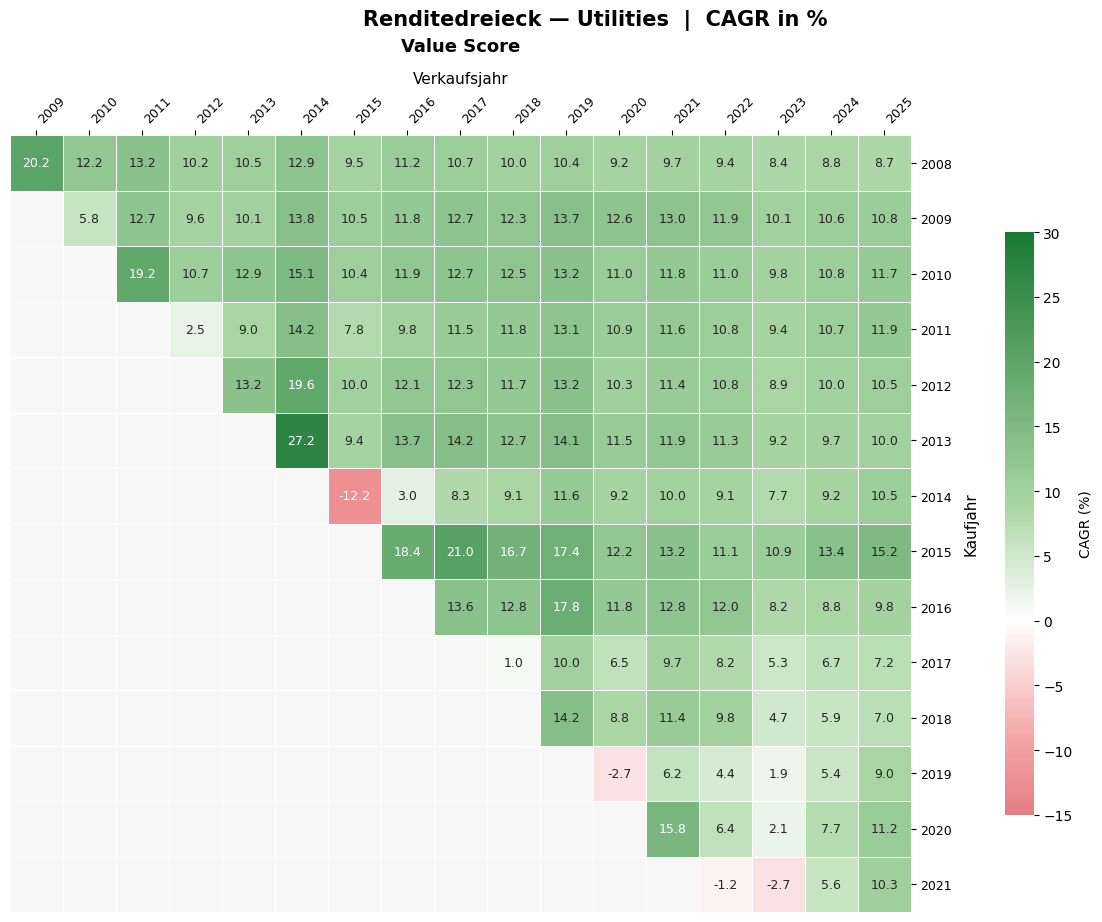

In [3]:
from backtest.renditedreieck import plot_renditedreieck

plot_renditedreieck(df, sector_name, "value_score", label="Value Score", save_path=save_path)

Gespeichert: backtest/attachments/utilities/momentum_score_Renditedreieck.png


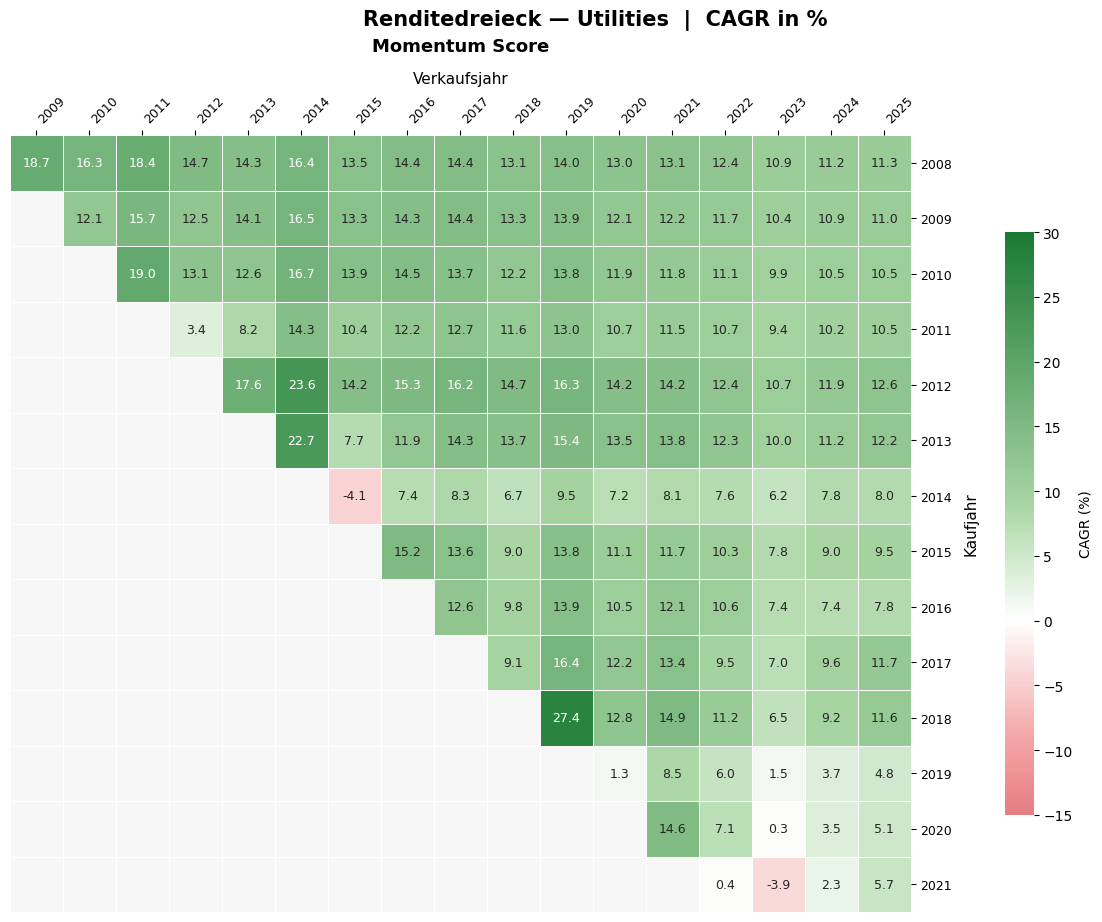

In [4]:
plot_renditedreieck(df, sector_name, "momentum_score", label="Momentum Score", save_path=save_path)

Gespeichert: backtest/attachments/utilities/delta_Deltadreieck.png


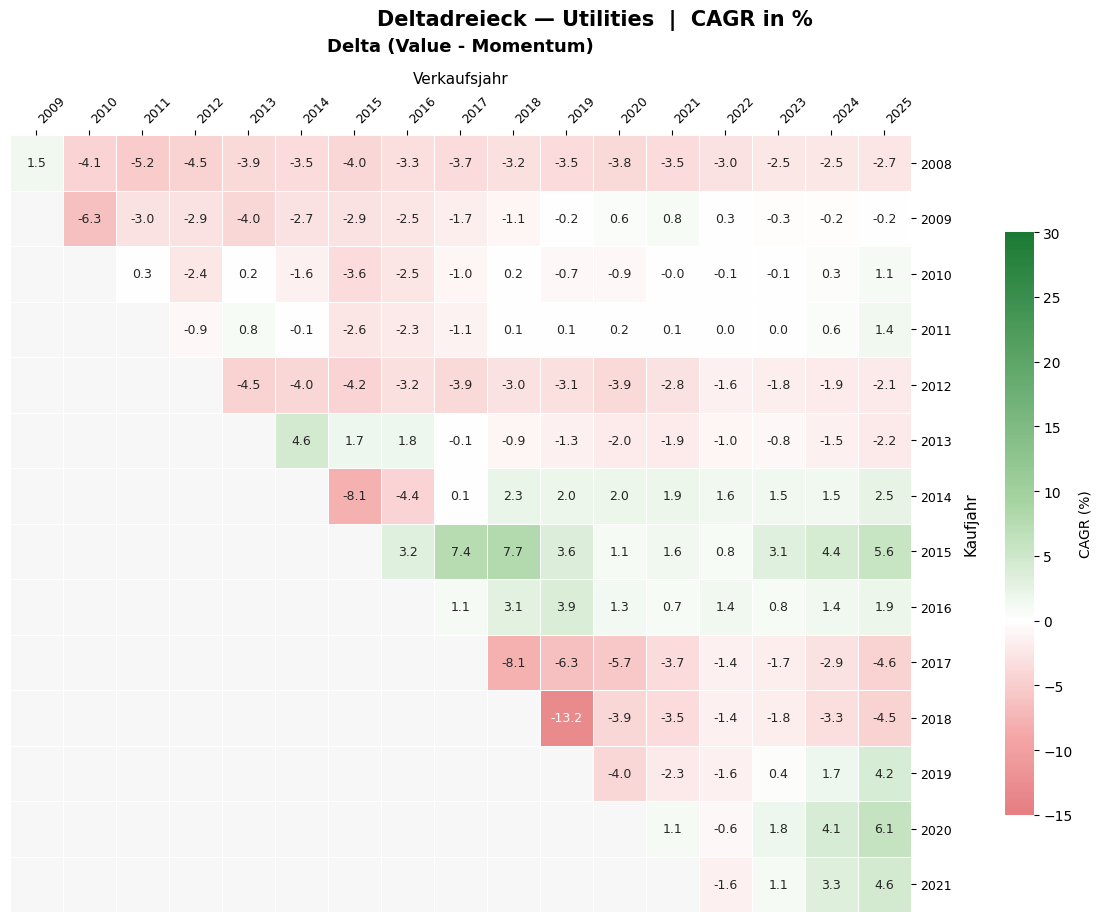

In [5]:

df_value = df[df["strategy"] == "value_score"].set_index(["buyyear", "sellyear", "sector"])["rendite"]
df_mom   = df[df["strategy"] == "momentum_score"].set_index(["buyyear", "sellyear", "sector"])["rendite"]


df_delta = (df_value - df_mom).reset_index()
df_delta.columns = ["buyyear", "sellyear", "sector", "rendite"]
df_delta["strategy"] = "delta"  # damit plot_renditedreieck funktioniert

plot_renditedreieck(df_delta, sector_name, "delta", label="Delta (Value - Momentum)", titel="Deltadreieck", save_path=save_path)


## 1, 3, 5 Jahres Ansicht


In [6]:
import plotly.express as px

In [7]:
df["horizon"] = df["sellyear"] - df["buyyear"]

df = df[df["horizon"].isin([1,3,5])]

horizons = [1,3,5]

print(df.pivot_table(
    index="sellyear",
    columns=["strategy", "horizon"],
    values="rendite"
    ).describe().T)

for h in horizons:
    df_filtered = df[df["horizon"] == h]
    
    fig = px.box(
        df_filtered,
        x="strategy",
        y="rendite",
        title=f"{h}-Jahres Rendite nach Strategie ",
        color="strategy",  # sorgt für unterschiedliche Farben
        color_discrete_sequence=px.colors.qualitative.Set2,
        points="all" 
    )
    fig.update_yaxes(title="Rendite (%)")
    fig.update_xaxes(title="Strategy")



    fig.update_layout(
        width=900,
        height=500,
        title_font_size=20,
        font=dict(size=14),
        template="simple_white",
        showlegend=False
    )
   
    fig.show()
    output_dir = Path(save_path) / sector_name.lower().replace(" ", "_")
    output_dir.mkdir(parents=True, exist_ok=True)

    file_path = output_dir / f"{h}_year_distribution.png"
    fig.write_image(file_path)


                        count       mean        std    min     25%     50%  \
strategy       horizon                                                       
momentum_score 1         14.0  12.145714   9.146188  -4.14  4.8050  13.610   
               3         14.0  10.777857   5.057669   0.33  8.4525  12.340   
               5         13.0  11.100000   4.075128   3.69  9.5100  12.120   
value_score    1         14.0   9.635714  10.973834 -12.24  1.3950  13.410   
               3         14.0  10.455714   4.661708   2.09  6.9975  10.705   
               5         13.0  10.427692   2.803180   4.69  9.8400  11.180   

                            75%    max  
strategy       horizon                  
momentum_score 1        18.4525  27.45  
               3        14.1150  18.38  
               5        13.9500  16.48  
value_score    1        17.7250  27.22  
               3        13.5500  17.77  
               5        12.3500  13.75  
